In [1]:
%pip install openneuro-py mne scikit-learn pandas matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
#Feature vector: 128 channels × 5 bands = 640 features per session

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from pathlib import Path

mne.set_log_level('WARNING')
%matplotlib inline

DATA_DIR = Path('../data/raw')
PROC_DIR  = Path('../data/processed')
OUT_DIR   = Path('../outputs')

SUBJECTS = ['001', '002', '003', '004', '005']
SESSIONS = list(range(1, 13))

GENRE_MAP = {
    1:'Deep House', 2:'Indie', 3:'Electronics', 4:'New Age',
    5:'Electronic Dance', 6:'Ambient', 7:'Hindustani Classical',
    8:'Indian Semi-Classical', 9:'Indian Folk', 10:'Soft Jazz',
    11:'Goth Rock', 12:'Progressive Instrumental Rock'
}

BANDS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8,  13),
    'beta':  (13, 30),
    'gamma': (30, 40),
}

WINDOW_SEC  = 5.0   # window length in seconds
OVERLAP     = 0.0

print('Setup complete.')
print(f'Features per session: 128 x {len(BANDS)} = {128*len(BANDS)}')

Setup complete.
Features per session: 128 x 5 = 640


In [8]:
##  Band Power Function

def extract_band_powers(data, sfreq, bands):
    freqs, psd = welch(data, fs=sfreq, nperseg=int(sfreq * 2))

    features   = []
    feat_names = []
    for ch_idx in range(data.shape[0]):
        for band_name, (lo, hi) in bands.items():
            idx        = np.logical_and(freqs >= lo, freqs <= hi)
            try:
                band_power = np.trapezoid(psd[ch_idx, idx], freqs[idx])
            except AttributeError:
                band_power = np.trapz(psd[ch_idx, idx], freqs[idx])
            features.append(band_power)
            feat_names.append(f'ch{ch_idx:03d}_{band_name}')

    return np.array(features), feat_names

def sliding_window_features(data, sfreq, bands, window_sec=5.0, overlap=0.5):
    """
    Slide a window over the signal and extract features from each window.
    """
    n_times     = data.shape[1]
    window_size = int(window_sec * sfreq)
    step_size   = int(window_size * (1 - overlap))

    all_features = []
    feat_names   = None

    start = 0
    while start + window_size <= n_times:
        window = data[:, start:start + window_size]
        feats, names = extract_band_powers(window, sfreq, bands)
        all_features.append(feats)
        if feat_names is None:
            feat_names = names
        start += step_size

    return np.array(all_features), feat_names


print('Functions ready.')
print(f'Window: {WINDOW_SEC}s, overlap: {OVERLAP*100:.0f}%')
print(f'Expected windows per 30s session: ~{int((30 - WINDOW_SEC) / (WINDOW_SEC * (1-OVERLAP)) + 1)}')

print('extract_band_powers() ready.')

Functions ready.
Window: 5.0s, overlap: 0%
Expected windows per 30s session: ~6
extract_band_powers() ready.


In [9]:
## Test on One Session

fif_file = PROC_DIR / 'sub-001_ses-01_clean.fif'
raw      = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
data     = raw.get_data()
sfreq    = raw.info['sfreq']
del raw

features, feat_names = extract_band_powers(data, sfreq, BANDS)
del data

print(f'Feature vector : {features.shape}')
print(f'Sample names   : {feat_names[:5]}')
print(f'Sample values  : {features[:5]}')         
print(f'Min/Max        : {features.min():.2e} / {features.max():.2e}')

Feature vector : (645,)
Sample names   : ['ch000_delta', 'ch000_theta', 'ch000_alpha', 'ch000_beta', 'ch000_gamma']
Sample values  : [1.22943027e-11 3.38187540e-12 5.05186147e-12 4.58162033e-12
 9.53825852e-13]
Min/Max        : 2.25e-13 / 4.88e-11


In [10]:
## Build Full Feature Matrix (60 sessions)

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)


all_features   = []
all_labels     = []
all_subjects   = []
all_sessions   = []
feat_names_ref = None
errors         = []

for sub in SUBJECTS:
    for ses in SESSIONS:
        fif_file = PROC_DIR / f'sub-{sub}_ses-{ses:02d}_clean.fif'
        genre    = GENRE_MAP[ses]

        if not fif_file.exists():
            errors.append((sub, ses))
            continue

        raw   = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
        data  = raw.get_data()
        sfreq = raw.info['sfreq']
        del raw

        feats, names = sliding_window_features(data, sfreq, BANDS, WINDOW_SEC, OVERLAP)
        del data

        for f in feats:
            all_features.append(f)
            all_labels.append(genre)
            all_subjects.append(sub)
            all_sessions.append(ses)

        if feat_names_ref is None:
            feat_names_ref = names

        print(f'[OK] sub-{sub} ses-{ses:02d} ({genre}) → {len(feats)} windows')

print(f'\nTotal samples : {len(all_features)}')
print(f'Errors        : {len(errors)}')

[OK] sub-001 ses-01 (Deep House) → 6 windows
[OK] sub-001 ses-02 (Indie) → 6 windows
[OK] sub-001 ses-03 (Electronics) → 6 windows
[OK] sub-001 ses-04 (New Age) → 6 windows
[OK] sub-001 ses-05 (Electronic Dance) → 6 windows
[OK] sub-001 ses-06 (Ambient) → 6 windows
[OK] sub-001 ses-07 (Hindustani Classical) → 6 windows
[OK] sub-001 ses-08 (Indian Semi-Classical) → 6 windows
[OK] sub-001 ses-09 (Indian Folk) → 6 windows
[OK] sub-001 ses-10 (Soft Jazz) → 6 windows
[OK] sub-001 ses-11 (Goth Rock) → 6 windows
[OK] sub-001 ses-12 (Progressive Instrumental Rock) → 6 windows
[OK] sub-002 ses-01 (Deep House) → 6 windows
[OK] sub-002 ses-02 (Indie) → 6 windows
[OK] sub-002 ses-03 (Electronics) → 6 windows
[OK] sub-002 ses-04 (New Age) → 6 windows
[OK] sub-002 ses-05 (Electronic Dance) → 6 windows
[OK] sub-002 ses-06 (Ambient) → 6 windows
[OK] sub-002 ses-07 (Hindustani Classical) → 6 windows
[OK] sub-002 ses-08 (Indian Semi-Classical) → 6 windows
[OK] sub-002 ses-09 (Indian Folk) → 6 windows
[O

In [11]:
## Save Feature Matrix

X  = np.array(all_features)
df = pd.DataFrame(X, columns=feat_names_ref)
df['label']   = all_labels
df['subject'] = all_subjects
df['session'] = all_sessions

csv_path = OUT_DIR / 'features.csv'
df.to_csv(csv_path, index=False)

print(f'Shape  : {df.shape}')
print(f'Saved  : {csv_path}')
print(f'\nSamples per genre:')
print(df['label'].value_counts().to_string())

Shape  : (360, 648)
Saved  : ../outputs/features.csv

Samples per genre:
label
Deep House                       30
Indie                            30
Electronics                      30
New Age                          30
Electronic Dance                 30
Ambient                          30
Hindustani Classical             30
Indian Semi-Classical            30
Indian Folk                      30
Soft Jazz                        30
Goth Rock                        30
Progressive Instrumental Rock    30


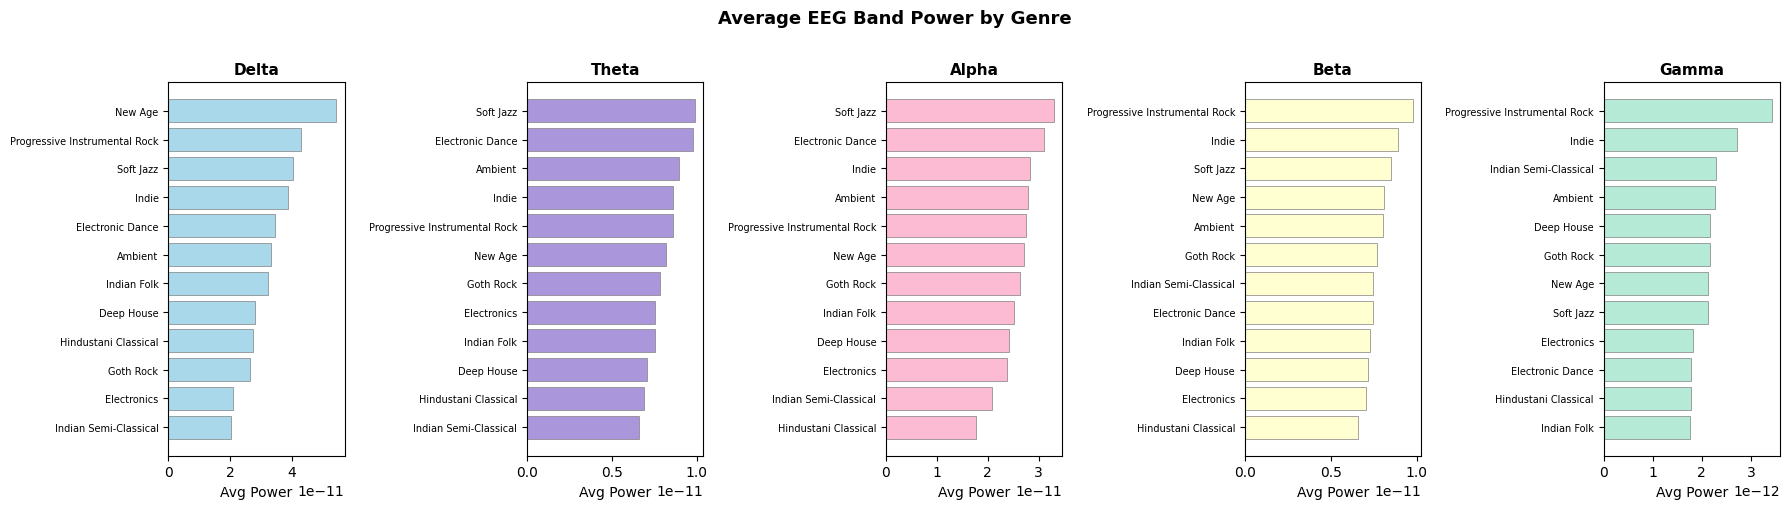

Saved: outputs/03_band_powers_by_genre.png


In [12]:
##  Visualize — Band Powers by Genre

# Average band power per genre (mean across all channels)
band_names = list(BANDS.keys())
summary = {}
for band in band_names:
    cols = [c for c in feat_names_ref if c.endswith(band)]
    summary[band] = df.groupby('label')[cols].mean().mean(axis=1)

summary_df = pd.DataFrame(summary)

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)
colors = ['#a8d8ea', '#aa96da', '#fcbad3', '#ffffd2', '#b5ead7']

for ax, band, color in zip(axes, band_names, colors):
    vals = summary_df[band].sort_values()
    ax.barh(vals.index, vals.values, color=color, edgecolor='gray', linewidth=0.5)
    ax.set_title(band.capitalize(), fontweight='bold', fontsize=11)
    ax.set_xlabel('Avg Power')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Average EEG Band Power by Genre', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / '03_band_powers_by_genre.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/03_band_powers_by_genre.png')

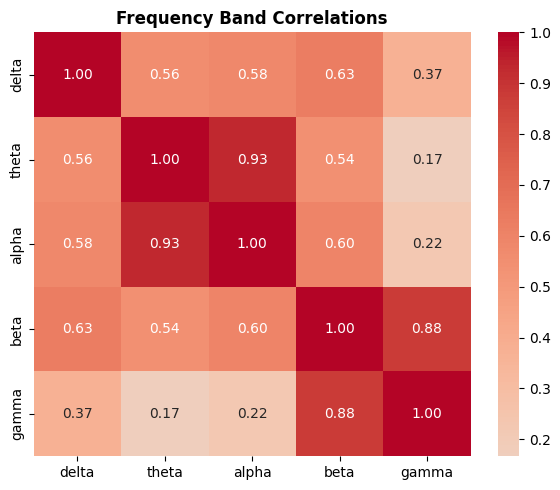

Saved: outputs/03_band_correlation.png


In [13]:
## Visualize — Band Correlation Heatmap

# Are bands correlated with each other?
corr_df = summary_df[band_names].T.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(summary_df[band_names].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Frequency Band Correlations', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '03_band_correlation.png', dpi=120)
plt.show()
print('Saved: outputs/03_band_correlation.png')
